Import libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import models,layers,Sequential
from tensorflow.keras.layers import Input,Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense, Dropout
from sklearn.metrics import classification_report,confusion_matrix

Explore and split the dataset into train and test parts

In [22]:
(x_train, y_train), (x_test, y_test) = keras.datasets.cifar10.load_data()

print("Training images:", x_train.shape)
print("Training labels:", y_train.shape)
print("Testing images:", x_test.shape)
print("Testing labels:", y_test.shape)

Training images: (50000, 32, 32, 3)
Training labels: (50000, 1)
Testing images: (10000, 32, 32, 3)
Testing labels: (10000, 1)


Class labels

In [23]:
class_names = [
    "airplane",
    "automobile",
    "bird",
    "cat",
    "deer",
    "dog",
    "frog",
    "horse",
    "ship",
    "truck"
]


Visualize sample images.

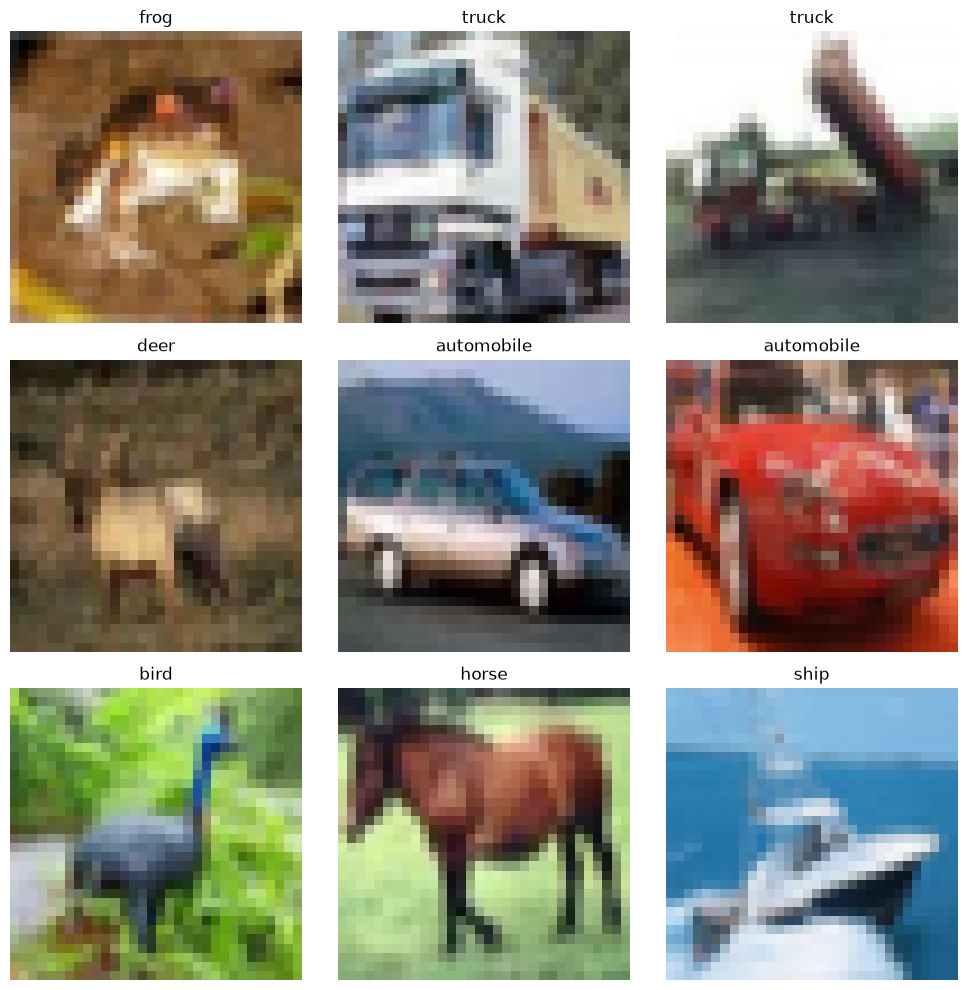

In [24]:
plt.figure(figsize=(10, 10))

for i in range(9):

    plt.subplot(3, 3, i + 1)

    plt.imshow(x_train[i])

    plt.title(class_names[y_train[i][0]])

    plt.axis("off")

plt.tight_layout()
plt.show()

Normalize the pixel values

In [25]:
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

Build the cnn model

In [26]:
model = keras.Sequential([

    layers.Input(shape=(32, 32, 3)),
    layers.Conv2D(32, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(128, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(10, activation="softmax")
])

In [27]:
model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 4, 4, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 2, 2, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 160,202 (625.79 KB)

 Trainable params: 160,202 (625.79 KB)

 Non-trainable params: 0 (0.00 B)

In [28]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [29]:
history = model.fit(
    x_train,
    y_train,
    validation_split=0.2,
    epochs=10,
    batch_size=64
)

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 12s 16ms/step - accuracy: 0.3553 - loss: 1.7413 - val_accuracy: 0.4743 - val_loss: 1.4669
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step - accuracy: 0.4997 - loss: 1.3867 - val_accuracy: 0.5550 - val_loss: 1.2590
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 9s 15ms/step - accuracy: 0.5645 - loss: 1.2409 - val_accuracy: 0.5988 - val_loss: 1.1225
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 10s 17ms/step - accuracy: 0.5977 - loss: 1.1417 - val_accuracy: 0.6330 - val_loss: 1.0401
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 11s 17ms/step - accuracy: 0.6331 - loss: 1.0510 - val_accuracy: 0.6572 - val_loss: 0.9809
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 10s 17ms/step - accuracy: 0.6586 - loss: 0.9746 - val_accuracy: 0.6614 - val_loss: 0.9691
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 10s 16ms/step - accuracy: 0.6809 - loss: 0.9190 - val_accuracy: 0.6609 - val_loss: 0.9888
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 11s 17ms/step - accuracy: 0.6957 - loss: 0.8733 - v

In [30]:
test_loss, test_accuracy = model.evaluate(
    x_test,
    y_test
)

print("Test Accuracy:", test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6954 - loss: 0.8698
Test Accuracy: 0.6953999996185303


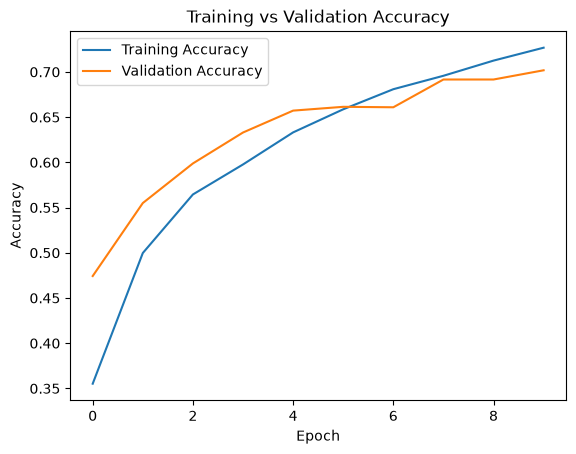

In [31]:
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.title("Training vs Validation Accuracy")

plt.legend()
plt.show()

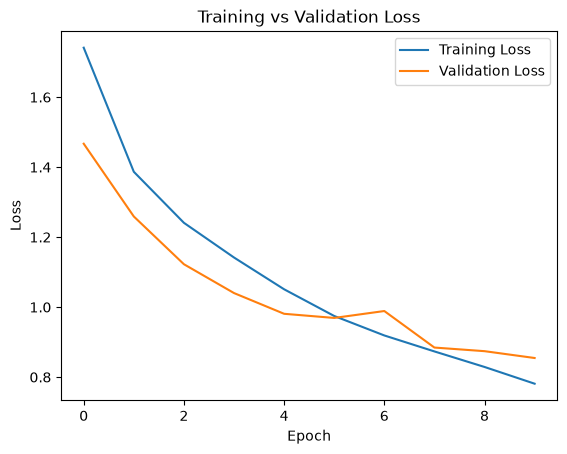

In [32]:
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title("Training vs Validation Loss")

plt.legend()
plt.show()

In [33]:
#confusion matrix and classification report
y_pred_prob = model.predict(x_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


In [34]:
y_pred = np.argmax(y_pred_prob, axis=1)


In [35]:
y_true = y_test.flatten()

In [36]:
print(y_pred.shape)
print(y_true.shape)

(10000,)
(10000,)


In [37]:
labels = list(range(10))

In [38]:
cm=confusion_matrix(y_true, y_pred, labels = labels)

In [39]:
#classification report

report = classification_report(y_true, y_pred, labels=labels, target_names=class_names)

In [40]:
print("Classification report:", report)

Classification report:               precision    recall  f1-score   support

    airplane       0.72      0.75      0.73      1000
  automobile       0.86      0.81      0.83      1000
        bird       0.57      0.61      0.59      1000
         cat       0.51      0.49      0.50      1000
        deer       0.60      0.68      0.64      1000
         dog       0.64      0.54      0.58      1000
        frog       0.73      0.79      0.76      1000
       horse       0.72      0.73      0.73      1000
        ship       0.80      0.81      0.81      1000
       truck       0.83      0.74      0.78      1000

    accuracy                           0.70     10000
   macro avg       0.70      0.70      0.70     10000
weighted avg       0.70      0.70      0.70     10000



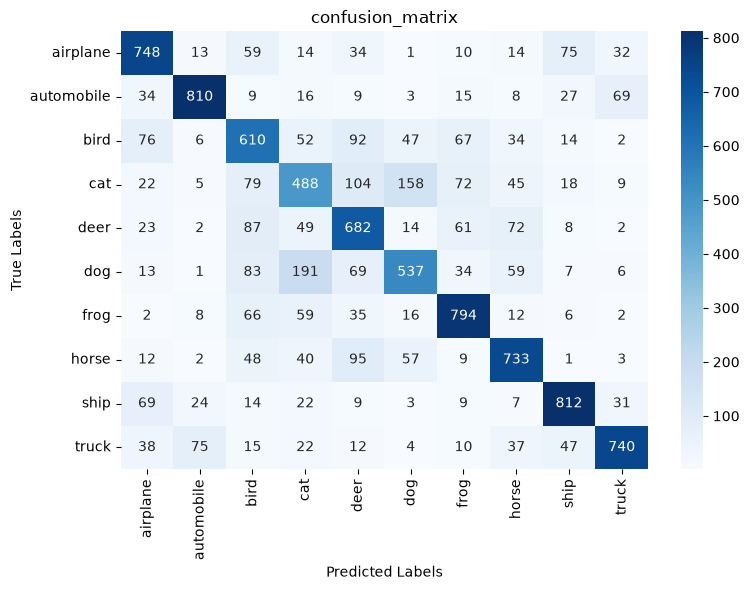

In [41]:
#confusion matrix heatmap

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names,yticklabels=class_names )

plt.title("confusion_matrix")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")

plt.tight_layout()
plt.show()

In [42]:
index = 11
image = x_test[index]

prediction = model.predict(
    np.expand_dims(image, axis=0)
)

predicted_class = np.argmax(prediction)

print("Actual Class:",
      class_names[y_test[index][0]])

print("Predicted Class:",
      class_names[predicted_class])

print("Confidence:",
      np.max(prediction) * 100)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 286ms/step
Actual Class: truck
Predicted Class: truck
Confidence: 99.95348


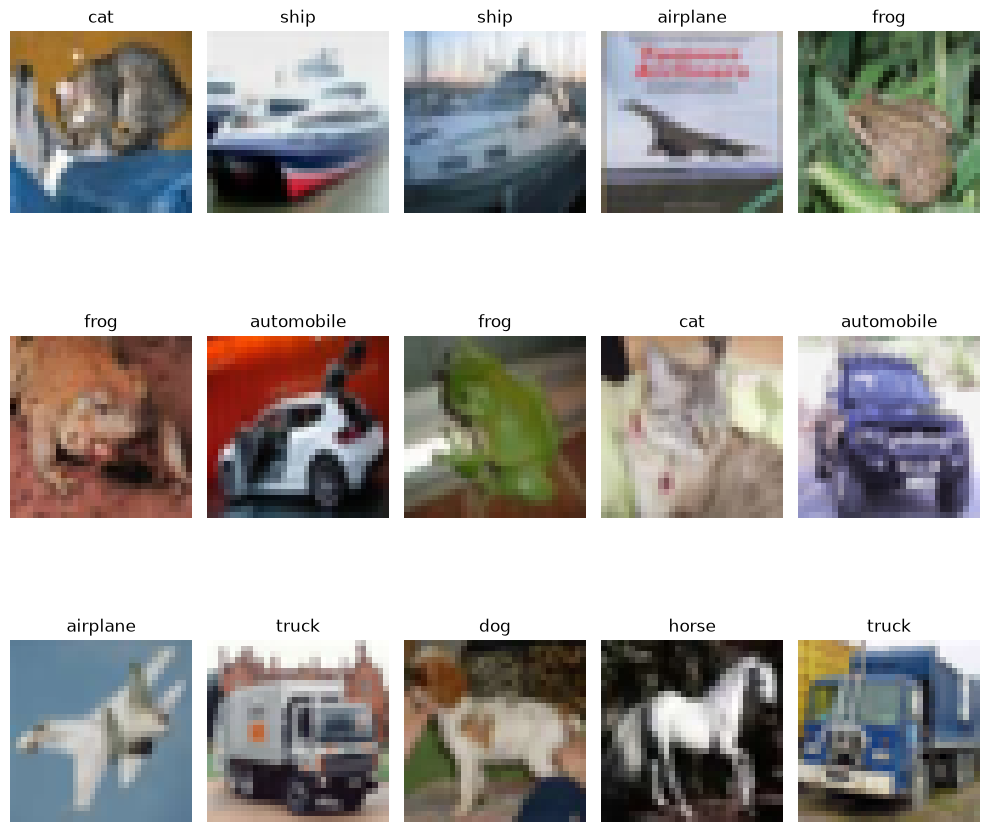

In [43]:
plt.figure(figsize=(10, 10))

for i in range(15):

    plt.subplot(3, 5, i + 1)

    plt.imshow(x_test[i])

    plt.title(class_names[y_test[i][0]])

    plt.axis("off")

plt.tight_layout()
plt.show()

CNN model using Transfer Learning

In [44]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.optimizers import Adam

In [55]:
x_train = tf.image.resize(x_train, (96, 96))
x_test = tf.image.resize(x_test, (96, 96))

In [56]:
base_model = MobileNetV2(weights='imagenet', include_top = False, input_shape = (96,96,3))

In [57]:
base_model.trainable = False
print(not base_model.trainable)

True


In [58]:
model = Sequential([layers.Input(shape = (96, 96, 3)),
                    base_model,layers.GlobalAveragePooling2D(),
                    layers.Dense(128,activation="relu"), 
                    layers.Dropout(0.3), 
                    layers.Dense(1,activation="sigmoid")])

In [59]:
model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_96             │ (None, 3, 3, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,081 (9.24 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [60]:
model.compile(optimizer = Adam(learning_rate = 0.001),loss="binary_crossentropy",metrics=['accuracy'])

In [61]:
history = model.fit(x_train,y_train, epochs = 5, validation_split=0.2)

Epoch 1/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 169s 131ms/step - accuracy: 0.0996 - loss: -153660.1406 - val_accuracy: 0.1014 - val_loss: -447782.9688
Epoch 2/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 155s 124ms/step - accuracy: 0.0997 - loss: -971558.5000 - val_accuracy: 0.1014 - val_loss: -1593888.8750
Epoch 3/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 176s 141ms/step - accuracy: 0.0997 - loss: -2390539.2500 - val_accuracy: 0.1014 - val_loss: -3265307.7500
Epoch 4/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 173s 139ms/step - accuracy: 0.0997 - loss: -4285240.0000 - val_accuracy: 0.1014 - val_loss: -5388329.5000
Epoch 5/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 153s 123ms/step - accuracy: 0.0997 - loss: -6621702.5000 - val_accuracy: 0.1014 - val_loss: -7924761.5000


In [63]:
transfer_loss , transfer_accuracy = model.evaluate(x_test,y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 30s 95ms/step - accuracy: 0.1000 - loss: -7915462.0000


In [64]:
print(transfer_loss)
print(transfer_accuracy)

-7915462.0
0.10000000149011612


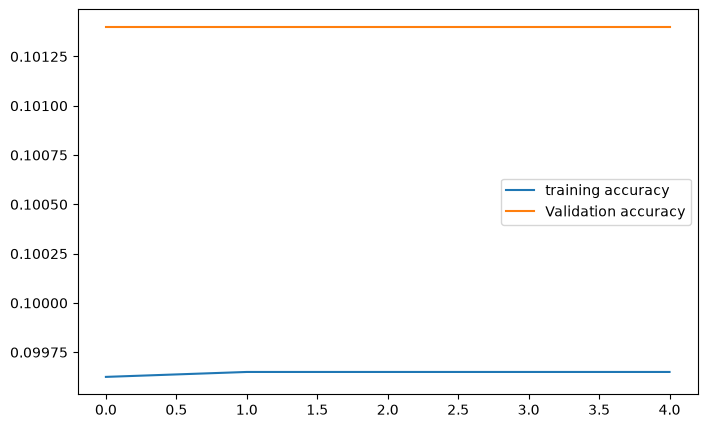

In [65]:
plt.figure(figsize = (8,5))
plt.plot(history.history['accuracy'], label = "training accuracy")
plt.plot(history.history['val_accuracy'],label="Validation accuracy")
plt.legend()
plt.show()

In [66]:
base_model.trainable = True

In [67]:
for layer in base_model.layers[:-20]:
    layer.trainable = False
for layer in base_model.layers:
    if isinstance(layer,layers.BatchNormalization):
        layer.trainable = False

In [70]:
trainable_layers = 0
frozen_layers = 0

In [71]:
for layer in base_model.layers:
    if layer.trainable:
        trainable_layers += 1
    else:
        frozen_layers += 1

In [72]:
print(trainable_layers)

13


In [73]:
print(frozen_layers)

141


In [74]:
model.compile(optimizer = Adam(learning_rate = 0.00001),loss="binary_crossentropy",metrics=['accuracy'])

In [75]:
fine_history =  model.fit(x_train,y_train,epochs=5, validation_split=0.2)

Epoch 1/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 213s 166ms/step - accuracy: 0.0997 - loss: -82883616.0000 - val_accuracy: 0.1014 - val_loss: -87048824.0000
Epoch 2/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 187s 150ms/step - accuracy: 0.0997 - loss: -87184784.0000 - val_accuracy: 0.1014 - val_loss: -87348360.0000
Epoch 3/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 191s 153ms/step - accuracy: 0.0997 - loss: -87401024.0000 - val_accuracy: 0.1014 - val_loss: -87642824.0000
Epoch 4/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 198s 158ms/step - accuracy: 0.0997 - loss: -87759904.0000 - val_accuracy: 0.1014 - val_loss: -87937040.0000
Epoch 5/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 192s 153ms/step - accuracy: 0.0997 - loss: -88035280.0000 - val_accuracy: 0.1014 - val_loss: -88231880.0000


In [76]:
fine_loss, fine_accuracy = model.evaluate(x_test, y_test)
print(fine_loss)
print(fine_accuracy)


313/313 ━━━━━━━━━━━━━━━━━━━━ 33s 104ms/step - accuracy: 0.1000 - loss: -88181456.0000
-88181456.0
0.10000000149011612


In [78]:
y_pred_prod = model.predict(x_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 32s 103ms/step


In [79]:
y_pred = np.argmax(y_pred_prob, axis=1)

In [80]:
y_true = y_test.flatten()

In [81]:
print(y_true.shape)

(10000,)


In [82]:
print(y_pred.shape)

(10000,)


In [83]:
labels=list(range(10))

In [ ]:
cm = confusion_matrix(y_true, y_pred,labels = labels)

In [ ]:
report = classification_report(y_true, y_pred, labels=labels, target_names=class_names)

In [86]:
print("classification report:", report)

classification report:               precision    recall  f1-score   support

           0       0.72      0.75      0.73      1000
           1       0.86      0.81      0.83      1000
           2       0.57      0.61      0.59      1000
           3       0.51      0.49      0.50      1000
           4       0.60      0.68      0.64      1000
           5       0.64      0.54      0.58      1000
           6       0.73      0.79      0.76      1000
           7       0.72      0.73      0.73      1000
           8       0.80      0.81      0.81      1000
           9       0.83      0.74      0.78      1000

    accuracy                           0.70     10000
   macro avg       0.70      0.70      0.70     10000
weighted avg       0.70      0.70      0.70     10000



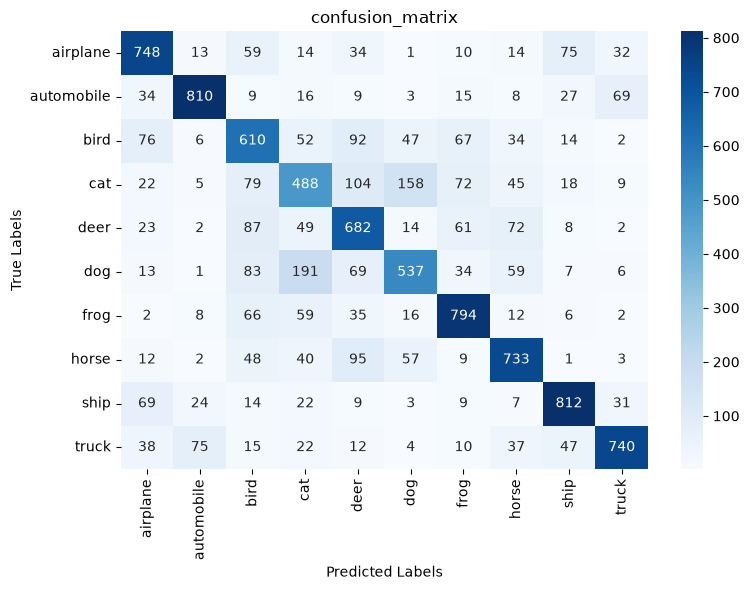

In [87]:
#confusion matrix heatmap

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names,yticklabels=class_names )

plt.title("confusion_matrix")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")

plt.tight_layout()
plt.show()

In [88]:
index = 11
image = x_test[index]

prediction = model.predict(
    np.expand_dims(image, axis=0)
)

predicted_class = np.argmax(prediction)

print("Actual Class:",
      class_names[y_test[index][0]])

print("Predicted Class:",
      class_names[predicted_class])

print("Confidence:",
      np.max(prediction) * 100)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 424ms/step
Actual Class: truck
Predicted Class: airplane
Confidence: 100.0


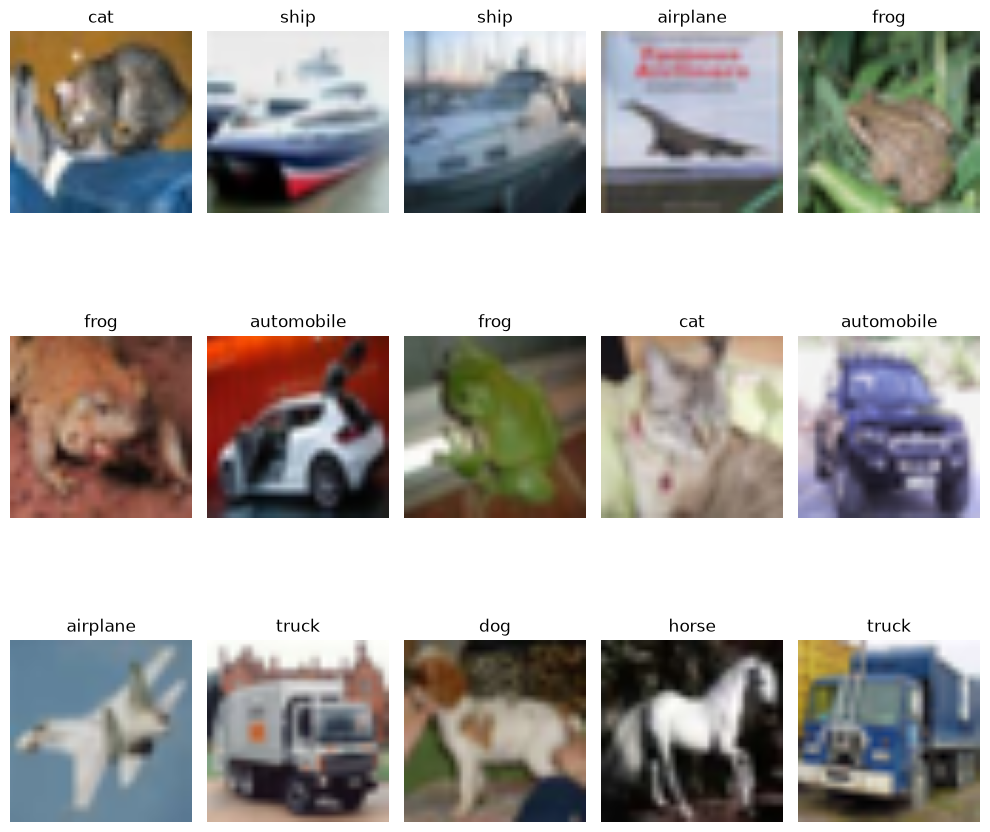

In [89]:
plt.figure(figsize=(10, 10))

for i in range(15):

    plt.subplot(3, 5, i + 1)

    plt.imshow(x_test[i])

    plt.title(class_names[y_test[i][0]])

    plt.axis("off")

plt.tight_layout()
plt.show()